In [1]:
# Installing Cudnn
!apt-cache policy c

# Install latest version
!apt install --allow-change-held-packages libcudnn8

# Export env variables
!export PATH=/usr/local/cuda-11.4/bin${PATH:+:${PATH}}
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/lib64:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=/usr/local/cuda-11.4/include:$LD_LIBRARY_PATH
!export LD_LIBRARY_PATH=$LD_LIBRARY_PATH:/usr/local/cuda/extras/CUPTI/lib64

N: Unable to locate package c



The following additional packages will be installed:
  libcudnn8-dev
The following held packages will be changed:
  libcudnn8
The following packages will be upgraded:
  libcudnn8 libcudnn8-dev
2 upgraded, 0 newly installed, 0 to remove and 127 not upgraded.
Need to get 885 MB of archives.
After this operation, 56.3 kB of additional disk space will be used.
Get:1 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  libcudnn8-dev 8.9.7.29-1+cuda12.2 [440 MB]
Get:2 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  libcudnn8 8.9.7.29-1+cuda12.2 [444 MB]
Fetched 885 MB in 10s (89.6 MB/s)

(Reading database ... 127400 files and directories currently installed.)
Preparing to unpack .../libcudnn8-dev_8.9.7.29-1+cuda12.2_amd64.deb ...
7Progress: [  0%] [..........................................................] 8update-alternatives: removing manually selected alternative - switching libcudnn to auto mode
7Prog

In [2]:
import os, glob, shutil, zipfile, gdown
import random, time, math, gc

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import PIL
import cv2
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn import metrics as skmetrics

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers, regularizers, callbacks, optimizers, losses

import tensorboard as tb

# metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report, roc_curve, auc

In [3]:
#original Link
# https://drive.google.com/file/d/19RFT4McuE7TblyjIkBTx8O8h7dmNOp3B/view?usp=sharing

# Global Variables
FILE_ID = "19RFT4McuE7TblyjIkBTx8O8h7dmNOp3B"
height, width = 128, 128
BATCH_SIZE=512

In [4]:
# Utility Function

# function to download the dataset from the url
def download_dataset_from_url(url, file_path):
    try:
        gdown.download(url, file_path, quiet=False)
        print(f"Successfully downloaded to {file_path}")
    except Exception as e:
        print(f"Error downloading file: {e}")

# function to unzip the file
def unzip_file_shutil(zip_path, extract_path):
    try:
        os.makedirs(extract_path, exist_ok=True)
        shutil.unpack_archive(zip_path, extract_path)
        print(f"Successfully extracted to {extract_path}")
    except Exception as e:
        print(f"Error extracting file: {e}")

def deleteLogs(log_path=""):

    if not log_path:
        log_path = os.path.join(os.getcwd(), "logs")
    try:
        shutil.rmtree(log_path)
        print(f"Deleted logs from {log_path}")
    except Exception as e:
        print(f"Error deleting logs: {e}")

def generate_logs_Folder(logfolderName="", usrTimestamp=True, clear_folder=False):
    currentPath = os.getcwd()

    # clear existing eventLogs if clear_folder is True
    if clear_folder:
        deleteLogs(os.path.join(currentPath, "logs"))

    if not os.path.exists(os.path.join(currentPath, "logs")):
        os.mkdir("logs")

    if logfolderName:
        if usrTimestamp:
            logfolderName = logfolderName + "_" + time.strftime("%Y%m%d-%H%M%S")
        else:
            logfolderName = logfolderName
        logName = os.path.join(currentPath, "logs", logfolderName)
        if not os.path.exists(logName):
            os.mkdir(logName)
    else:
        logName = os.path.join(currentPath, "logs")

    return logName

def generate_logs_Name(fileName, logFormat=".log", clear_folder=False):
    folderName = generate_logs_Folder(fileName, clear_folder=clear_folder)
    fileName = fileName + "_" + time.strftime("%Y%m%d-%H%M%S") + logFormat
    return os.path.join(folderName, fileName)

# load and imshow png file from the path
def showUnetArchitecture(path):
    img = plt.imread(path)
    plt.show()

In [5]:
def download_and_prep_dataset(FILE_ID):
    url = f'https://drive.google.com/uc?id={FILE_ID}'
    currentPath = os.getcwd()
    print("CWD: ", currentPath)
    dataSet_path = os.path.abspath(os.path.join(currentPath, "dataSet/ModelDataSet.zip"))
    extractPath = os.path.abspath(os.path.join(currentPath, "unzipLoc/"))

    # create directory if not exists
    if not os.path.exists(os.path.abspath(os.path.join(currentPath, "dataSet/"))):
        os.mkdir(os.path.abspath(os.path.join(currentPath, "dataSet/")))

    if not os.path.exists(extractPath):
        os.mkdir(extractPath)

    # download the dataset
    if not os.path.exists(dataSet_path):
        download_dataset_from_url(url=url, file_path=dataSet_path)

    # unzip the dataset
    if os.listdir(extractPath) == []:
        unzip_file_shutil(zip_path=dataSet_path, extract_path=extractPath)

    # Load the dataset
    return extractPath

def visualizeDataSize(dataSet, maskDataSet, k=4):
  randIdx = random.sample(range(0, len(dataSet)), k)
  fig, axs = plt.subplots(nrows=k, ncols=2, figsize=(8, 8))
  for i, idx in enumerate(randIdx):
    axs[i, 0].imshow(dataSet[idx])
    axs[i, 1].imshow(maskDataSet[idx])
  plt.tight_layout()
  plt.show()

def diceCoefficient(y_true, y_pred, smooth=1):
    y_true_f = tf.keras.backend.flatten(y_true)
    y_pred_f = tf.keras.backend.flatten(y_pred)

    intersection = tf.keras.backend.sum(y_true_f * y_pred_f)
    return (2. * intersection + smooth) / (tf.keras.backend.sum(y_true_f) + tf.keras.backend.sum(y_pred_f) + smooth)

def preprocess(train_data, val_data, test_data, target_height=128, target_width=128):

    # Data Processing Stage with resizing and rescaling operations
    data_preprocess = keras.Sequential(
        name="data_preprocess",
        layers=[
            layers.Resizing(target_height, target_width),
            layers.Rescaling(1.0/255),
        ]
    )

    # Perform Data Processing on the train, val, test dataset
    train_ds = train_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    val_ds = val_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    test_ds = test_data.map(lambda x, y: (data_preprocess(x), y), num_parallel_calls=tf.data.AUTOTUNE)

    return train_ds, val_ds, test_ds

CWD:  /kaggle/working


Downloading...
From (original): https://drive.google.com/uc?id=19RFT4McuE7TblyjIkBTx8O8h7dmNOp3B
From (redirected): https://drive.google.com/uc?id=19RFT4McuE7TblyjIkBTx8O8h7dmNOp3B&confirm=t&uuid=021be56c-ca9c-4c15-84a2-09f4d653e28b
To: /kaggle/working/dataSet/ModelDataSet.zip
100%|██████████| 876M/876M [00:03<00:00, 261MB/s]


Successfully downloaded to /kaggle/working/dataSet/ModelDataSet.zip
Successfully extracted to /kaggle/working/unzipLoc
/kaggle/working/unzipLoc


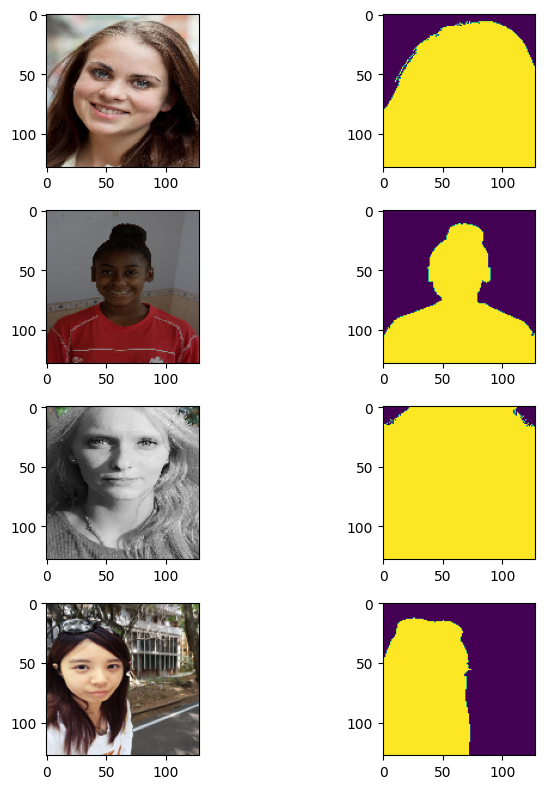

In [6]:
# prepare the Dataset
dl_ext_data_path = download_and_prep_dataset(FILE_ID=FILE_ID)
print(dl_ext_data_path)

## load data
ImgData = np.load(os.path.join(dl_ext_data_path, "img_uint8.npy"))
MaskData = np.load(os.path.join(dl_ext_data_path, "msk_uint8.npy"))

visualizeDataSize(ImgData, MaskData)

MaskData[MaskData > 0] = 1

#### Data Exploration

In [7]:
print("ImgData.shape: ", ImgData.shape)
print("MaskData.shape: ", MaskData.shape)

print(f"IMAGE - pixel Value- Max : {np.max(ImgData)}, Min: {np.min(ImgData)}")
print(f"MASK  - pixel Value- Max : {np.max(MaskData)}, Min: {np.min(MaskData)}")

# Scaling and preparing the data.
yCateg = tf.keras.utils.to_categorical(MaskData)
del MaskData
gc.collect()

ImgData.shape:  (18698, 128, 128, 3)
MaskData.shape:  (18698, 128, 128, 1)
IMAGE - pixel Value- Max : 255, Min: 0
MASK  - pixel Value- Max : 1, Min: 0


20490

In [8]:
print("yCateg.shape: ", yCateg.shape)
print("ImageData.shape: ", ImgData.shape)
XTrain, XTest, yTrain, yTest = train_test_split(ImgData, yCateg, test_size=0.2, random_state=42)

print("XTrain.shape: ", XTrain.shape)
print("yTrain.shape: ", yTrain.shape)
print("XTest.shape: ", XTest.shape)
print("yTest.shape: ", yTest.shape)

del ImgData
del yCateg
gc.collect()

yCateg.shape:  (18698, 128, 128, 2)
ImageData.shape:  (18698, 128, 128, 3)
XTrain.shape:  (14958, 128, 128, 3)
yTrain.shape:  (14958, 128, 128, 2)
XTest.shape:  (3740, 128, 128, 3)
yTest.shape:  (3740, 128, 128, 2)


0

In [9]:
# Load the TensorBoard notebook extension
%load_ext tensorboard

# Clear any logs from previous runs
!rm -rf ./logs/

In [10]:
def fcVgg16_Encoder_decoder_model(inpShape = (128, 128, 3)):
    VGG16 = tf.keras.applications.VGG16(weights="imagenet",
                                        include_top=False,
                                        input_tensor=tf.keras.Input(shape=(128, 128, 3)))
    VGG16.trainable  = False
    x = VGG16(VGG16.input)

    #Decoder
    o = tf.keras.layers.Conv2D( 4096 , ( 7 , 7 ) , activation='relu' , padding='same', name="conv6")(x)
    conv7 = tf.keras.layers.Conv2D( 4096 , ( 1 , 1 ) , activation='relu' , padding='same', name="conv7")(o)
    print(o.shape,conv7.shape)

    ## 4 times upsamping for pool4 layer
    conv7_4 = tf.keras.layers.Conv2DTranspose( 2 , kernel_size=(4,4) ,  strides=(4,4) , use_bias=False)(conv7)

    ## 2 times upsampling for pool411

    pool4 = VGG16.get_layer('block4_pool').output
    pool411 = tf.keras.layers.Conv2D( 2 , ( 1 , 1 ) , activation='relu' , padding='same', name="pool4_11")(pool4)
    pool411_2 = tf.keras.layers.Conv2DTranspose(2 , kernel_size=(2,2) ,  strides=(2,2) , use_bias=False)(pool411)

    pool3 = VGG16.get_layer('block3_pool').output
    pool311 = tf.keras.layers.Conv2D(2 , ( 1 , 1 ) , activation='relu' , padding='same', name="pool3_11")(pool3)
    o = tf.keras.layers.Add(name="add")([pool411_2, pool311])

    print(o.shape,conv7_4.shape)
    o = tf.keras.layers.Add(name="add1")([o, conv7_4 ])
    o = tf.keras.layers.Conv2DTranspose(2 , kernel_size=(8,8) ,  strides=(8,8) , use_bias=False)(o)
    o = tf.keras.layers.Activation('softmax')(o)

    model = tf.keras.Model(VGG16.input, o)

    return model

In [11]:
model = fcVgg16_Encoder_decoder_model()
a = keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file='fcn8.jpeg')

58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
(None, 4, 4, 4096) (None, 4, 4, 4096)
(None, 16, 16, 2) (None, 16, 16, 2)


In [12]:
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=["accuracy", diceCoefficient])

history = model.fit(XTrain, yTrain, batch_size=48, epochs=10, validation_data=(XTest, yTest))

Epoch 1/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 66s 176ms/step - accuracy: 0.5372 - dice_coefficient: 0.5119 - loss: 3.4613 - val_accuracy: 0.9224 - val_dice_coefficient: 0.8808 - val_loss: 0.2078
Epoch 2/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - accuracy: 0.9342 - dice_coefficient: 0.9022 - loss: 0.1728 - val_accuracy: 0.9370 - val_dice_coefficient: 0.9093 - val_loss: 0.1561
Epoch 3/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - accuracy: 0.9489 - dice_coefficient: 0.9255 - loss: 0.1250 - val_accuracy: 0.9419 - val_dice_coefficient: 0.9213 - val_loss: 0.1442
Epoch 4/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - accuracy: 0.9556 - dice_coefficient: 0.9361 - loss: 0.1059 - val_accuracy: 0.9444 - val_dice_coefficient: 0.9264 - val_loss: 0.1400
Epoch 5/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - accuracy: 0.9594 - dice_coefficient: 0.9417 - loss: 0.0960 - val_accuracy: 0.9456 - val_dice_coefficient: 0.9304 - val_loss: 0.1411
Epoch 6/10
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step 

In [13]:
model.save("VGG16_Model.keras")

In [14]:
def visualizePredictedData(model, dataSet, maskDataSet, k=4):
    randIdx = random.sample(range(0, len(dataSet)), k)
    fig, axs = plt.subplots(nrows=k, ncols=3, figsize=(8, 8))
    predMask = model.predict(dataSet)
    maskDataSet = np.argmax(maskDataSet, axis=-1)
    predMask = np.argmax(predMask, axis=-1)
    for i, idx in enumerate(randIdx):
        axs[i, 0].imshow(dataSet[idx])
        axs[i, 0].set_title("original Image")
        axs[i, 1].imshow(maskDataSet[idx])
        axs[i, 1].set_title("original Mask")
        axs[i, 2].imshow(predMask[idx])
        axs[i, 2].set_title("Predicted Mask")
    plt.tight_layout()
    plt.show()

117/117 ━━━━━━━━━━━━━━━━━━━━ 12s 66ms/step


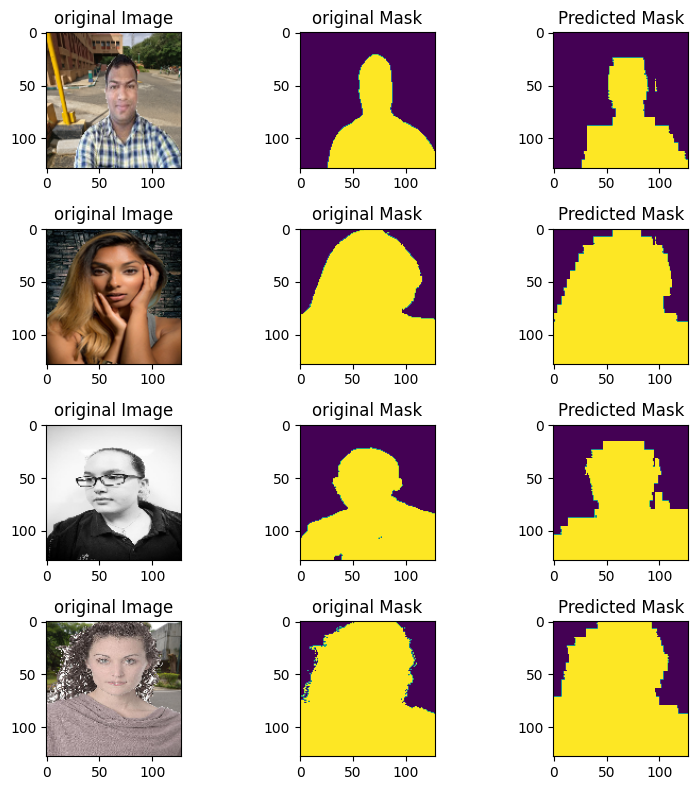

In [15]:
visualizePredictedData(model, XTest, yTest)

The quality of preditions are not as good as expected because of a shallow network. We can improve the model by making the network deeper on the decoder side

### UNET Model

In [16]:
def encoder(inpLayer, nKernal):
    lyr = keras.layers.Conv2D(filters=nKernal, kernel_size=(3, 3), padding='same')(inpLayer)
    lyr = keras.layers.LeakyReLU(alpha=0.1)(lyr)
    lyr = keras.layers.Conv2D(filters=nKernal, kernel_size=(3, 3), padding='same')(lyr)
    lyr = keras.layers.LeakyReLU(alpha=0.1)(lyr)
    lyr = keras.layers.MaxPooling2D(pool_size=(2, 2))(lyr)
    return lyr

def decoder(inpLayer, encoderLayer, nKernal):
    lyr = keras.layers.Conv2DTranspose(filters=nKernal, kernel_size=(2, 2), strides=(2, 2), padding='same')(inpLayer)
    lyr = keras.layers.concatenate([lyr, encoderLayer])
    lyr = keras.layers.Conv2D(filters=nKernal, kernel_size=(3, 3), padding='same')(lyr)
    lyr = keras.layers.LeakyReLU(alpha=0.1)(lyr)
    lyr = keras.layers.Conv2D(filters=nKernal, kernel_size=(3, 3), padding='same')(lyr)
    lyr = keras.layers.LeakyReLU(alpha=0.1)(lyr)
    return lyr

In [17]:
def uNET_model():
    inpLayer = keras.layers.Input(shape=(128, 128, 3))
    # Encoder
    encoder1 = encoder(inpLayer, 64)
    encoder2 = encoder(encoder1, 128)
    bottleNeck = encoder(encoder2, 256)

    # Decoder
    decoder1 = decoder(bottleNeck, encoder2, 128)
    decoder2 = decoder(decoder1, encoder1, 64)
    decoder3 = decoder(decoder2, inpLayer, 32)
    outLayer = keras.layers.Conv2D(filters=2, kernel_size=(1, 1), activation='sigmoid')(decoder3)
    model = keras.models.Model(inputs=inpLayer, outputs=outLayer)
    return model

In [18]:
model = uNET_model()
a = keras.utils.plot_model(model, show_shapes=True, show_layer_names=True, to_file='uNET.jpeg')

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
              loss=tf.keras.losses.CategoricalCrossentropy(),
              metrics=["accuracy", diceCoefficient])

tensorboard_logs = generate_logs_Name("uNET")
tensorboard = callbacks.TensorBoard(log_dir=tensorboard_logs, histogram_freq=1)
lrscheduler = keras.callbacks.ReduceLROnPlateau(monitor='val_dice_coefficient', factor=0.1, patience=5, verbose=1, mode="max")
earlyStopp = keras.callbacks.EarlyStopping(monitor='val_dice_coefficient', patience=7, verbose=1, mode="max")
history = model.fit(XTrain, yTrain, batch_size=48, epochs=40, validation_data=(XTest, yTest), callbacks=[tensorboard, lrscheduler, earlyStopp])

Epoch 1/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 73s 179ms/step - accuracy: 0.6988 - dice_coefficient: 0.1420 - loss: 1.2333 - val_accuracy: 0.8457 - val_dice_coefficient: 0.2587 - val_loss: 0.3876 - learning_rate: 0.0010
Epoch 2/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.8864 - dice_coefficient: 0.3031 - loss: 0.2992 - val_accuracy: 0.9231 - val_dice_coefficient: 0.4187 - val_loss: 0.2092 - learning_rate: 0.0010
Epoch 3/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 124ms/step - accuracy: 0.9295 - dice_coefficient: 0.4181 - loss: 0.1904 - val_accuracy: 0.9482 - val_dice_coefficient: 0.4736 - val_loss: 0.1410 - learning_rate: 0.0010
Epoch 4/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.9497 - dice_coefficient: 0.4969 - loss: 0.1361 - val_accuracy: 0.9537 - val_dice_coefficient: 0.5151 - val_loss: 0.1271 - learning_rate: 0.0010
Epoch 5/40
312/312 ━━━━━━━━━━━━━━━━━━━━ 39s 125ms/step - accuracy: 0.9553 - dice_coefficient: 0.5301 - loss: 0.1221 - val_accuracy: 0.9569 - val_dic

In [19]:
model.save("Unet_Model.keras")

117/117 ━━━━━━━━━━━━━━━━━━━━ 9s 47ms/step


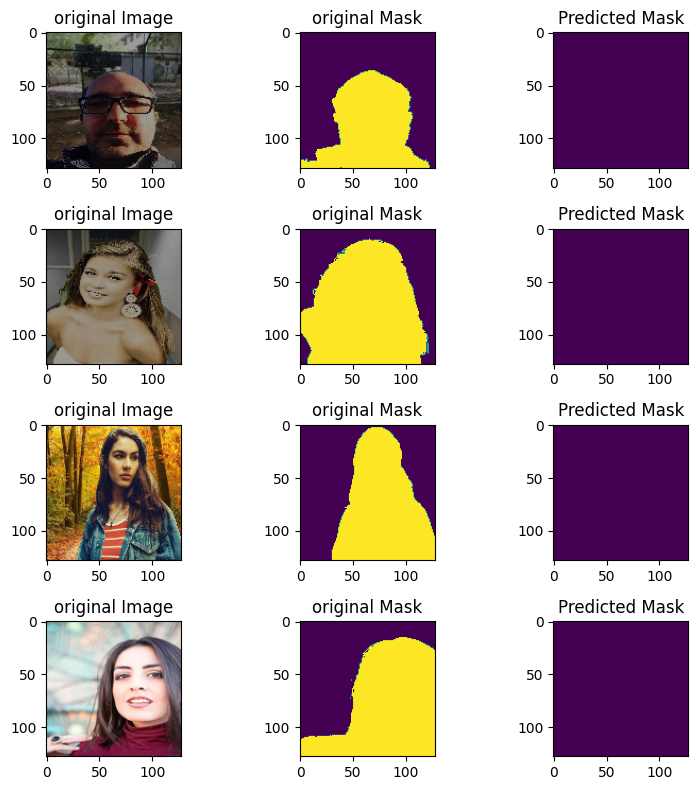

In [20]:
visualizePredictedData(model, XTest, yTest)